# Load MNIST with PyTorch

In [1]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [2]:
transform = transforms.ToTensor()

In [3]:
train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    transform=transform,
    download=True
)

In [4]:
test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    transform=transform,
    download=True
)

In [5]:
print("Training samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

Training samples: 60000
Test samples: 10000


In [6]:
image, label = train_dataset[0]

print("Image shape:", image.shape)
print("Label:", label)

Image shape: torch.Size([1, 28, 28])
Label: 5


In [7]:
print(image.min())
print(image.max())

tensor(0.)
tensor(1.)


In [8]:
print(image[0, :5, :5])

tensor([[0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.]])


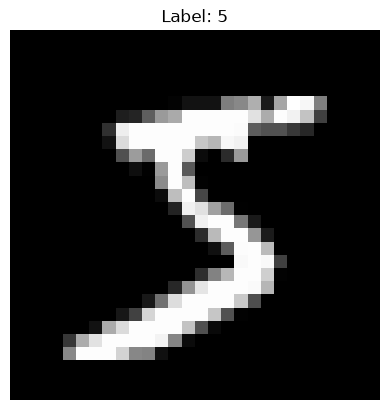

In [9]:
import matplotlib.pyplot as plt

plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"Label: {label}")
plt.axis("off")
plt.show()

In [10]:
batch_size = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [11]:
images, labels = next(iter(train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

Images shape: torch.Size([64, 1, 28, 28])
Labels shape: torch.Size([64])


In [12]:
labels

tensor([4, 9, 3, 0, 3, 7, 9, 0, 3, 8, 6, 3, 0, 6, 3, 4, 3, 9, 0, 2, 9, 6, 7, 4,
        4, 1, 5, 9, 5, 2, 6, 4, 3, 4, 4, 6, 3, 5, 1, 3, 5, 8, 2, 8, 8, 6, 7, 2,
        6, 0, 8, 6, 9, 2, 6, 7, 9, 8, 4, 8, 5, 4, 7, 3])

In [13]:
images_flat = images.view(images.size(0), -1)

print(images_flat.shape)

torch.Size([64, 784])


# Build the MNIST ANN

In [14]:
import torch
import torch.nn as nn

class MNIST_ANN(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(784, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 10)
        )

    def forward(self, x):
        x = x.reshape(x.size(0), -1)
        return self.network(x)

In [15]:
model = MNIST_ANN()

print(model)

MNIST_ANN(
  (network): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)


In [16]:
images, labels = next(iter(train_loader))

print("Images:", images.shape)
print("Labels:", labels.shape)

Images: torch.Size([64, 1, 28, 28])
Labels: torch.Size([64])


In [17]:
logits = model(images)

print("Logits:", logits.shape)

Logits: torch.Size([64, 10])


In [18]:
logits

tensor([[ 6.2721e-02,  6.1938e-02,  3.7413e-02, -3.3156e-02, -2.9295e-02,
         -6.5158e-02,  2.6208e-02,  5.6653e-02, -3.8150e-04, -1.9957e-02],
        [ 1.5664e-02,  5.8314e-02,  7.6764e-03,  1.7002e-03,  5.0599e-03,
         -3.7171e-02, -1.4447e-03,  1.2402e-03,  2.9322e-03, -2.9904e-02],
        [ 9.2512e-02,  6.1020e-02,  1.7495e-02, -1.2785e-02,  2.8275e-02,
         -9.5162e-02,  1.7774e-02, -1.9784e-02, -2.8720e-02,  1.2211e-02],
        [ 5.9848e-02,  4.1138e-02,  9.0173e-03, -8.4420e-03,  3.6628e-02,
         -9.2125e-02, -7.4611e-03, -3.0185e-02, -3.0560e-02,  5.7253e-02],
        [ 3.8304e-02,  5.7287e-02,  3.3945e-02, -1.6351e-02, -1.2830e-02,
         -6.2832e-02,  1.6257e-02,  1.9586e-02,  3.1642e-03, -4.2629e-02],
        [ 8.4916e-02,  3.1924e-02,  3.8096e-02, -4.7064e-02, -2.2012e-02,
         -1.0230e-01,  8.6694e-03, -7.4309e-03, -2.7899e-02, -3.2210e-03],
        [ 6.3949e-02,  6.7569e-02,  2.6087e-02, -1.7347e-02, -2.6557e-02,
         -7.0126e-02,  2.7554e-0

In [19]:
predictions = torch.argmax(logits, dim=1)

print("Predictions:", predictions)
print("Actual:", labels)

Predictions: tensor([0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 2, 2, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 2, 1,
        0, 1, 1, 1, 2, 0, 0, 0, 1, 0, 0, 0, 1, 0, 8, 0, 1, 6, 4, 2, 1, 0, 0, 1,
        0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0])
Actual: tensor([5, 1, 0, 0, 4, 7, 0, 6, 9, 7, 7, 4, 6, 6, 3, 8, 1, 9, 2, 1, 1, 1, 8, 2,
        7, 8, 9, 5, 5, 2, 8, 0, 2, 7, 0, 7, 7, 9, 8, 7, 0, 4, 2, 6, 8, 3, 7, 9,
        7, 6, 9, 5, 1, 5, 4, 6, 7, 8, 2, 4, 0, 6, 0, 1])


# Train and Evaluate the MNIST ANN 

In [20]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [21]:
num_epochs = 5

for epoch in range(num_epochs):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        # 1. Forward pass
        logits = model(images)

        # 2. Calculate loss
        loss = criterion(logits, labels)

        # 3. Clear old gradients
        optimizer.zero_grad()

        # 4. Backpropagation
        loss.backward()

        # 5. Update weights
        optimizer.step()

        # Statistics
        running_loss += loss.item()

        predictions = torch.argmax(logits, dim=1)

        correct += (predictions == labels).sum().item()
        a

    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = correct / total

    print(
        f"Epoch {epoch+1}/{num_epochs} "
        f"Loss: {epoch_loss:.4f} "
        f"Accuracy: {epoch_accuracy:.4f}"
    )

Epoch 1/5 Loss: 0.3369 Accuracy: 0.9055
Epoch 2/5 Loss: 0.1412 Accuracy: 0.9583
Epoch 3/5 Loss: 0.0958 Accuracy: 0.9709
Epoch 4/5 Loss: 0.0699 Accuracy: 0.9788
Epoch 5/5 Loss: 0.0536 Accuracy: 0.9832


In [22]:
model.eval()

correct = 0
total = 0
val_loss = 0.0

with torch.no_grad():

    for images, labels in test_loader:

        logits = model(images)

        loss = criterion(logits, labels)

        val_loss += loss.item()

        predictions = torch.argmax(logits, dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

val_loss /= len(test_loader)
val_accuracy = correct / total

print(
    f"Val Loss: {val_loss:.4f} "
    f"Val Accuracy: {val_accuracy:.4f}"
)

Val Loss: 0.0811 Val Accuracy: 0.9751


In [24]:
images, labels = next(iter(test_loader))

model.eval()

with torch.no_grad():
    logits = model(images)
    predictions = torch.argmax(logits, dim=1)

In [25]:
print("Predicted:", predictions[:10])
print("Actual:   ", labels[:10])

Predicted: tensor([7, 2, 1, 0, 4, 1, 4, 9, 5, 9])
Actual:    tensor([7, 2, 1, 0, 4, 1, 4, 9, 5, 9])


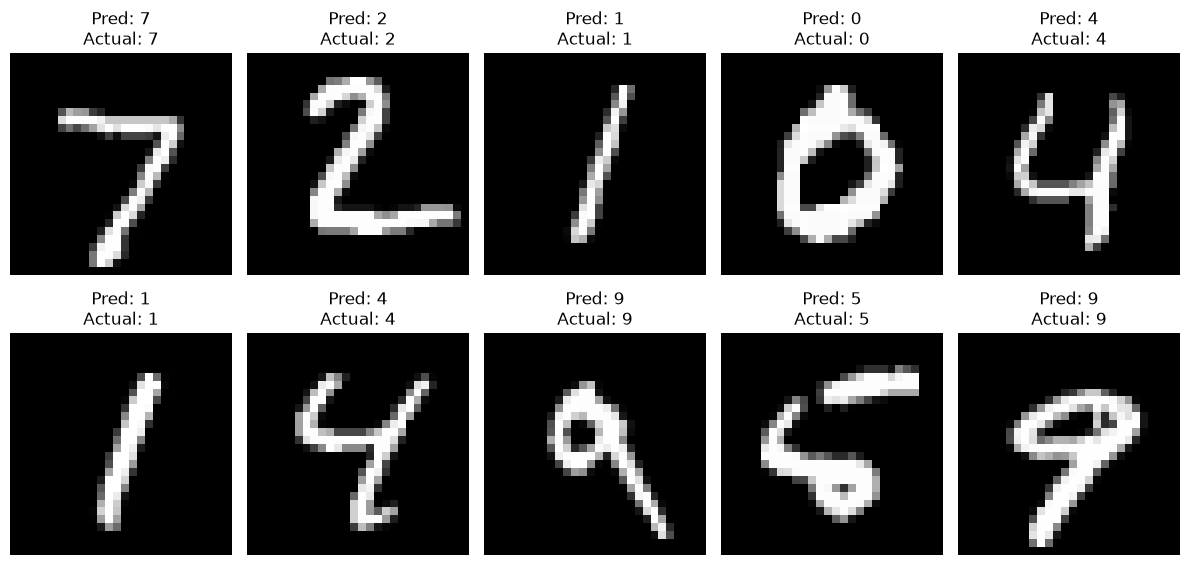

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for i in range(10):

    plt.subplot(2, 5, i + 1)

    plt.imshow(images[i].squeeze(), cmap="gray")

    plt.title(
        f"Pred: {predictions[i].item()}\n"
        f"Actual: {labels[i].item()}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [27]:
wrong_images = []
wrong_labels = []
wrong_predictions = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        logits = model(images)
        predictions = torch.argmax(logits, dim=1)

        wrong = predictions != labels

        wrong_images.append(images[wrong])
        wrong_labels.append(labels[wrong])
        wrong_predictions.append(predictions[wrong])

In [28]:
print("Number of wrong predictions:", len(wrong_images))

Number of wrong predictions: 157


In [29]:
wrong_images = torch.cat(wrong_images)
wrong_labels = torch.cat(wrong_labels)
wrong_predictions = torch.cat(wrong_predictions)

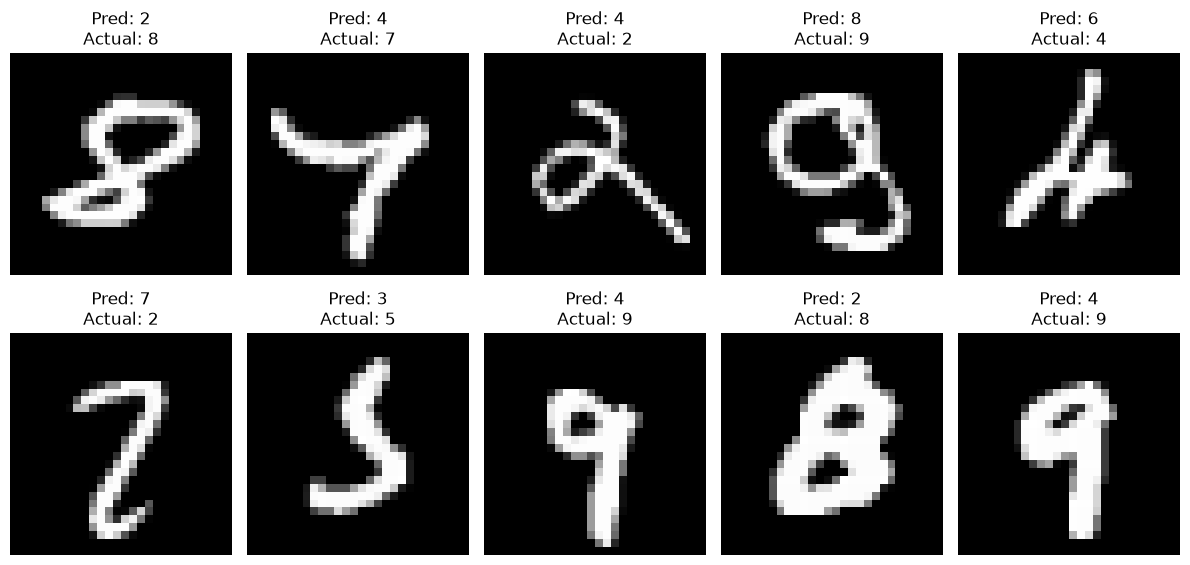

In [30]:
plt.figure(figsize=(12, 6))

for i in range(10):

    plt.subplot(2, 5, i + 1)

    plt.imshow(
        wrong_images[i].squeeze(),
        cmap="gray"
    )

    plt.title(
        f"Pred: {wrong_predictions[i].item()}\n"
        f"Actual: {wrong_labels[i].item()}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

# Confusion Matrix

In [31]:
all_labels = []
all_predictions = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        logits = model(images)

        predictions = torch.argmax(logits, dim=1)

        all_labels.extend(labels.tolist())
        all_predictions.extend(predictions.tolist())

In [32]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    all_labels,
    all_predictions
)

print(cm)

[[ 967    0    1    1    1    1    4    2    3    0]
 [   0 1122    3    1    0    0    2    1    6    0]
 [   5    1 1002    1    8    0    4    7    4    0]
 [   0    0    5  984    3    3    1    4    3    7]
 [   1    0    1    0  976    0    3    1    0    0]
 [   3    0    0    6    1  867    7    1    2    5]
 [   1    3    1    1    4    2  943    0    3    0]
 [   1    3   10    1    7    0    0 1002    0    4]
 [   6    0    8    5    8    2    5    3  932    5]
 [   3    2    0    3   35    2    0    6    2  956]]


In [33]:
class_accuracy = cm.diagonal() / cm.sum(axis=1)

for digit, acc in enumerate(class_accuracy):

    print(
        f"Digit {digit}: {acc * 100:.2f}%"
    )

Digit 0: 98.67%
Digit 1: 98.85%
Digit 2: 97.09%
Digit 3: 97.43%
Digit 4: 99.39%
Digit 5: 97.20%
Digit 6: 98.43%
Digit 7: 97.47%
Digit 8: 95.69%
Digit 9: 94.75%
